# `2D_Vortex_JIT` — output analysis

Interactive analysis of a run written by `python -m vortex_jit` (`setup.h5` + `fields.h5`).

1. **View** — pressure & electrostatic potential side by side, frame by frame (slider).
2. **Modes** — poloidal-mode (m-number) amplitude spectrum on a circle `r = rho`, plus the
   linear growth rate `gamma = d ln|a_m|/dt` (auto-detected exponential phase).

Edit the **Parameters** cell, then Run All.

## Setup

In [43]:
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
%matplotlib inline

from scipy.interpolate import CubicSpline

### Parameters — edit these

In [44]:
# --- run directory (must contain setup.h5 and fields.h5) ---
RUNDIR = "/pscratch/sd/d/dnzy06/plasma_sim_runs/test/56219033"          # <<< point at your run"

# --- coordinate system ---
COORD  = "auto"               # "auto" (detect from setup.h5) | "cart" | "polar"

# --- mode-analysis settings ---
FIELD  = "phi"                # field to Fourier-analyse: "phi" | "pres" | "vort"
RHO    = 0.30                 # ring radius for the poloidal analysis (units of L0) --
                               # used only when RHO_AVERAGED is False
MMAX   = 8                    # highest poloidal mode number m
NTHETA = 256                  # azimuthal sample points (cart ring interp; polar uses native)
RHO_AVERAGED = True           # True: average the mode spectrum over several rho (below)
                               # instead of sampling a single ring at RHO
N_SAMPLE_POINTS = 10          # number of rho samples when RHO_AVERAGED
LIMITER_RHO = 1.5             # rho samples span [0.1, LIMITER_RHO - 0.1]
# growth-rate fit: soft amplitude bounds (fraction of peak) for the AUTO linear-window
# search -- LO skips the seed-noise floor, HI skips the saturation roll-over.  The window
# itself is found automatically (max R^2), so these rarely need tuning.
LO, HI = 0.0, 0.9

### Helper functions

In [45]:
def sample_ring(field2d, x, y, rho, ntheta):
    """Bilinear-interpolate a (ny,nx) field onto ntheta points on the circle
    r=rho (centre origin), with periodic wrap at the domain edges.
    rho may be a scalar (-> returns shape (ntheta,)) or a 1-D array of several
    radii (-> returns shape (N, ntheta), one row per rho) for rho-averaging."""
    theta = np.arange(ntheta) * (2.0 * np.pi / ntheta)
    rho_in = rho
    rho_arr = np.atleast_1d(rho).astype(float)
    rho_col = rho_arr[:, None]
    xs = rho_col * np.cos(theta); ys = rho_col * np.sin(theta)
    nx = x.size; ny = y.size
    dx = x[1] - x[0]; dy = y[1] - y[0]
    fi = (xs - x[0]) / dx; fj = (ys - y[0]) / dy
    i0 = np.floor(fi).astype(int); j0 = np.floor(fj).astype(int)
    ti = fi - i0; tj = fj - j0
    i0m = i0 % nx; i1m = (i0 + 1) % nx
    j0m = j0 % ny; j1m = (j0 + 1) % ny
    f = field2d
    result = (f[j0m, i0m] * (1 - ti) * (1 - tj) + f[j0m, i1m] * ti * (1 - tj)
              + f[j1m, i0m] * (1 - ti) * tj + f[j1m, i1m] * ti * tj)
    if np.ndim(rho_in) == 0:
        return theta, result[0]      # shape (ntheta,) for scalar rho
    return theta, result             # shape (N, ntheta) for array rho

def mode_amplitudes(ring, mmax):
    """|a_m|, m=0..mmax (m>=1 folds the +/-m pair -> peak amplitude of that harmonic)."""
    N = ring.size
    amp = np.abs(np.fft.rfft(ring) / N)
    amp[1:] *= 2.0
    return amp[: mmax + 1]

def fit_growth(t, a, lo=0.0, hi=0.9, wmin=5):
    t = np.asarray(t, float); a = np.asarray(a, float)
    none = (np.nan, np.nan, np.nan, np.nan, np.zeros_like(a, bool))
    good = np.isfinite(a) & (a > 0)
    if good.sum() < wmin:
        return none
    amax = a[good].max()

    # was: imax = int(np.argmax(a))   <-- global max, lets the window reach past
    #                                      the first peak into the dip/plateau
    d = np.diff(a)
    neg = np.where(d < 0)[0]
    imax = int(neg[0]) if neg.size else len(a) - 1   # first local max instead

    cand = good & (a >= lo * amax) & (a <= hi * amax)
    cand[imax + 1:] = False                              # rising part only
    ii = np.where(cand)[0]
    if ii.size < wmin:
        ii = np.where(good[:imax + 1])[0]
    if ii.size < wmin:
        return none
    ll = np.full_like(a, -np.inf); ll[good] = np.log(a[good])
    best = (-np.inf, np.nan, np.nan, np.nan, np.nan, None)
    for p in range(ii.size - wmin + 1):
        for q in range(p + wmin - 1, ii.size):
            seg = ii[p:q + 1]; ts = t[seg]; ls = ll[seg]
            g, b = np.polyfit(ts, ls, 1)
            # if g <= 0:
            #     continue
            pred = g * ts + b
            r2 = 1.0 - np.sum((ls - pred) ** 2) / max(np.sum((ls - ls.mean()) ** 2), 1e-30)
            score = r2 * np.sqrt(seg.size)
            if score > best[0]:
                best = (score, g, ts[0], ts[-1], r2, seg)
    if best[5] is None:
        return none
    _, g, t0, t1, r2, seg = best
    mask = np.zeros_like(a, bool); mask[seg] = True
    return g, t0, t1, r2, mask

def fit_growth_manual(t, a, t0, t1):
    """Same return signature as fit_growth (g, t0, t1, r2, mask), but YOU pick
    the window [t0, t1] instead of letting the auto-detector choose it."""
    t = np.asarray(t, float); a = np.asarray(a, float)
    mask = (t >= t0) & (t <= t1) & np.isfinite(a) & (a > 0)
    if mask.sum() < 2:
        return np.nan, np.nan, np.nan, np.nan, mask
    ts = t[mask]; ls = np.log(a[mask])
    g, b = np.polyfit(ts, ls, 1)
    pred = g * ts + b
    r2 = 1.0 - np.sum((ls - pred) ** 2) / max(np.sum((ls - ls.mean()) ** 2), 1e-30)
    return g, ts[0], ts[-1], r2, mask

### Load data

In [46]:
# --- load, coordinate-aware.  cart: setup has x,y (1D) + fields (ny,nx).
#     polar: setup has r,theta (1D) + x,y (2D meshes) + fields (nr,ntheta),
#     tagged by the attribute coord_type="polar". ---
_setup = h5py.File(os.path.join(RUNDIR, "setup.h5"), "r")
attrs = dict(_setup.attrs)
COORD_EFF = (attrs.get("coord_type", "cart") if COORD == "auto" else COORD)
t_bar   = float(attrs.get("t_bar", 1.0))
P_bar   = float(attrs.get("P_bar", 1.0))
phi_bar = float(attrs.get("phi_bar", 1.0))

if COORD_EFF == "polar":
    r  = np.asarray(_setup["r"], float);  theta = np.asarray(_setup["theta"], float)
    X2 = np.asarray(_setup["x"], float);  Y2 = np.asarray(_setup["y"], float)   # (nr,ntheta)
    nr = r.size; rmax_dom = float(r.max())
else:
    x = np.asarray(_setup["x"], float);  y = np.asarray(_setup["y"], float)
    rmax_dom = float(np.hypot(max(abs(x[0]), abs(x[-1])), max(abs(y[0]), abs(y[-1]))))
_setup.close()

def ring_at(field2d, rho):
    """Field sampled on the circle(s) r=rho.  rho may be a scalar (single ring) or
    a 1-D array (used for the rho-averaged spectrum, one row per rho).  Returns
    shape (ntheta,) for scalar rho, (N, ntheta) for array rho.
    polar: linear radial interpolation onto the native theta grid.
    cart:  bilinear-interpolated ring via sample_ring."""
    if COORD_EFF == "polar":
        scalar_input = np.ndim(rho) == 0
        rho_arr = np.atleast_1d(rho).astype(float)
        j = np.clip(np.searchsorted(r, rho_arr), 1, nr - 1)
        w = (rho_arr - r[j - 1]) / (r[j] - r[j - 1])
        result = (1 - w)[:, None] * field2d[j - 1] + w[:, None] * field2d[j]
        return result[0] if scalar_input else result   # (ntheta,) or (N, ntheta)
    _, ring = sample_ring(field2d, x, y, rho, NTHETA)
    return ring

def draw_field(ax, F, cmap, vmin, vmax):
    """imshow (cart) or closed-disk pcolormesh (polar); returns the mappable."""
    if COORD_EFF == "polar":
        Xc = np.concatenate([X2, X2[:, :1]], axis=1)      # close the theta seam
        Yc = np.concatenate([Y2, Y2[:, :1]], axis=1)
        Fc = np.concatenate([F,  F[:, :1]],  axis=1)
        im = ax.pcolormesh(Xc, Yc, Fc, cmap=cmap, vmin=vmin, vmax=vmax, shading="gouraud")
    else:
        im = ax.imshow(F, origin="lower", extent=[x.min(), x.max(), y.min(), y.max()],
                       cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_aspect("equal"); return im

fh = h5py.File(os.path.join(RUNDIR, "fields.h5"), "r")   # lazy reads
t  = np.asarray(fh["t"], float); nf = fh["phi"].shape[0]
print(f"coord = {COORD_EFF}   |   {nf} frames, t in [{t[0]:.3f}, {t[-1]:.3f}] t_bar "
      f"(t_bar={t_bar:.3e} s)")
print(f"field shape {tuple(fh['phi'].shape[1:])}   domain max radius ~ {rmax_dom:.3f} L0")

coord = polar   |   51 frames, t in [0.000, 20.000] t_bar (t_bar=4.000e-04 s)
field shape (256, 512)   domain max radius ~ 2.994 L0


## 1. View — pressure & potential side by side

Use the slider (needs `ipywidgets`); otherwise the fallback shows the last frame,
or set `FRAME` in the next cell.

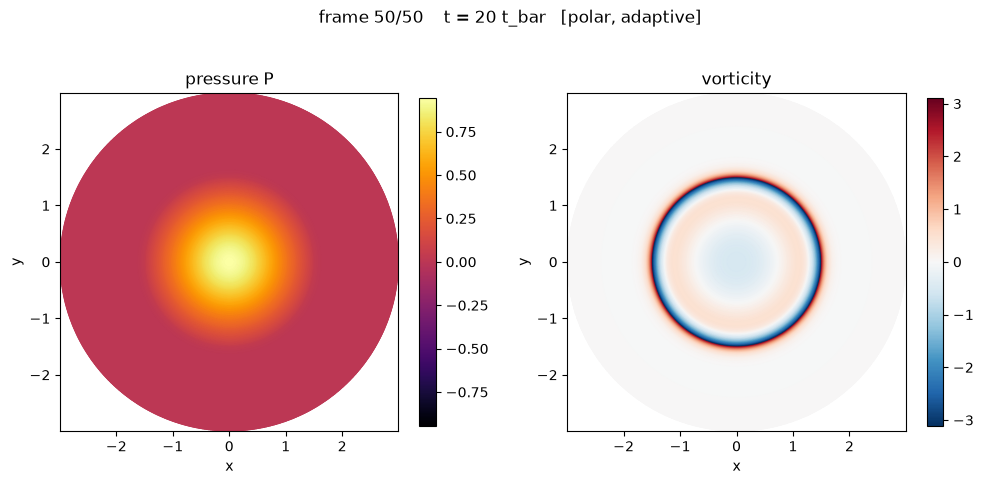

In [47]:
ADAPTIVE = True   # True: colour limits auto-scale to EACH frame (best for seeing the
                  # instability pattern early on); False: fixed limits across all frames.

# fixed limits (used only when ADAPTIVE = False), from first & last frames
_Pmax_fix = max(np.asarray(fh["pres"][0]).max(), np.asarray(fh["pres"][nf - 1]).max())
_Vm_fix   = max(np.abs(np.asarray(fh["vort"][0])).max(),
                np.abs(np.asarray(fh["vort"][nf - 1])).max()) or 1.0

def show_frame(i):
    i = int(np.clip(i, 0, nf - 1))
    P = np.asarray(fh["pres"][i]); V = np.asarray(fh["vort"][i])
    if ADAPTIVE:
        Pmin, Pmax = float(P.min()), float(P.max()); Vm = float(np.abs(V).max()) or 1.0
    else:
        Pmin, Pmax, Vm = 0.0, _Pmax_fix, _Vm_fix
    fig, (axP, axV) = plt.subplots(1, 2, figsize=(12, 5.2))
    imP = draw_field(axP, P, "inferno", -Pmax, Pmax)     # imshow (cart) / pcolormesh (polar)
    imV = draw_field(axV, V, "RdBu_r", -Vm, Vm)
    axP.set_title("pressure P"); axV.set_title("vorticity")
    for ax in (axP, axV):
        ax.set_xlabel("x"); ax.set_ylabel("y")
    fig.colorbar(imP, ax=axP, shrink=0.82); fig.colorbar(imV, ax=axV, shrink=0.82)
    fig.suptitle(f"frame {i}/{nf - 1}    t = {t[i]:.4g} t_bar   "
                 f"[{COORD_EFF}, {'adaptive' if ADAPTIVE else 'fixed'}]"); plt.show()

# Fast, dependency-free render of one frame (change the index, e.g. 0, nf//2, nf-1):
show_frame(50)

In [7]:
## --- OPTIONAL: interactive frame scrubber (needs the ipywidgets FRONT-END enabled) ---
## If this shows "loading" forever, the widget front-end isn't enabled: either run
##   pip install ipywidgets jupyterlab_widgets   (then restart kernel + refresh),
## or just skip this cell and use show_frame(i) / the montage below (no widgets needed).
#try:
#    from ipywidgets import interact, IntSlider
#    interact(show_frame, i=IntSlider(min=0, max=nf - 1, step=1, value=nf - 1,
#                                     continuous_update=False))   # redraw on release only
#except Exception as e:
#    print("ipywidgets unavailable:", e, "-> use show_frame(i) or the montage below.")

In [ ]:
# --- Widget-free evolution montage: N frames across the run (per-frame adaptive) ---
# (needs the Load cell run first, which defines draw_field / COORD_EFF)
idxs = np.linspace(0, nf - 1, 6).astype(int)
fig, axes = plt.subplots(2, len(idxs), figsize=(2.6 * len(idxs), 4.2),
                         constrained_layout=True)     # robust w/ pcolormesh + equal aspect
for c, k in enumerate(idxs):
    P = np.asarray(fh["pres"][k]); V = np.asarray(fh["phi"][k])

    ampP = np.fft.rfft(P)
    ampP[:, 0] = 0
    P = np.fft.irfft(ampP, n=np.shape(P)[1])

    ampV = np.fft.rfft(V)
    ampV[:, 0] = 0
    V = np.fft.irfft(ampV, n=np.shape(V)[1])

    vm = float(np.abs(V).max()) or 1.0
    pmn, pmx = float(P.min()), float(P.max())
    if pmx <= pmn:
        pmx = pmn + 1e-30
    imP = draw_field(axes[0, c], P, "inferno", pmn, pmx)
    imV = draw_field(axes[1, c], V, "RdBu_r", -vm, vm)
    axes[0, c].set_title(f"t={t[k]:.3f}", fontsize=9)
    fig.colorbar(imP, ax=axes[0, c], shrink=0.85)
    fig.colorbar(imV, ax=axes[1, c], shrink=0.85)
    for rr in (0, 1):
        axes[rr, c].tick_params(axis="both", labelsize=5)
        axes[rr, c].locator_params(axis="both", nbins=3)  # keep tiny ticks uncluttered
axes[0, 0].set_ylabel("pressure P"); axes[1, 0].set_ylabel("potential phi")
fig.suptitle(f"evolution montage ({COORD_EFF}, per-frame adaptive colour)")
plt.show()

In [22]:
t = np.asarray(fh["t"])
pres = np.asarray(fh["pres"])   # (nframe, nr, ntheta) -- P
vort = np.asarray(fh["vort"])  

In [37]:
# --- Where/when does pressure first go negative? ---
# Uses fh, t, nf, COORD_EFF, draw_field (Load data cell) and r/theta/X2/Y2 (polar)
# or x/y (cart), already defined above -- no new file handles opened.

k0 = None
for k in range(nf):
    Pk = np.asarray(fh["pres"][k])
    if (Pk < 0).any():
        k0 = k
        break

if k0 is None:
    print("Pressure never goes negative in this run.")
else:
    Pk = np.asarray(fh["pres"][k0])
    mask = Pk < 0
    n_neg = int(mask.sum())
    i_min, j_min = np.unravel_index(np.argmin(Pk), Pk.shape)

    if COORD_EFF == "polar":
        Xc, Yc = X2, Y2
        loc_str = (f"i={i_min} (r={r[i_min]:.4f} L0), j={j_min} "
                   f"(theta={theta[j_min]:.4f} rad = {np.degrees(theta[j_min]):.1f} deg)")
    else:
        Xc, Yc = np.meshgrid(x, y)          # shape (ny, nx), matches Pk
        loc_str = f"i={i_min} (y={y[i_min]:.4f}), j={j_min} (x={x[j_min]:.4f})"

    print(f"Pressure first goes negative at frame {k0}, t={t[k0]:.4f}")
    print(f"  most negative value: P={Pk[i_min, j_min]:.4e}, at {loc_str}")
    print(f"  {n_neg} of {Pk.size} grid points negative at this frame "
          f"({100 * n_neg / Pk.size:.2f}% of the grid)")

    fig, ax = plt.subplots(figsize=(5.5, 5))
    vmax = np.abs(Pk).max()
    im = draw_field(ax, Pk, "inferno", -vmax, vmax)
    ax.scatter(Xc[mask], Yc[mask], color="lime", marker=".", s=6, linewidths=0,
               label=f"P<0 ({n_neg} pts)")
    ax.set_title(f"pressure at frame {k0} (t={t[k0]:.4f}) -- first negative frame  [{COORD_EFF}]")
    ax.legend(markerscale=3)
    fig.colorbar(im, ax=ax, shrink=0.85)
    plt.tight_layout()
    plt.show()

Pressure never goes negative in this run.


## 2. Poloidal-mode spectrum & linear growth rate

Samples `FIELD` on the circle `r = RHO`, Fourier-analyses in the azimuthal angle,
and fits the growth rate over the auto-detected exponential phase.

In [38]:
T0_MANUAL, T1_MANUAL = 0.0, 6.3

def _rho_label():
    return "rho-averaged" if RHO_AVERAGED else f"rho={rho:.2f} L0"

rho = RHO
if rho > rmax_dom:
    print(f"WARNING: RHO={rho} exceeds domain radius {rmax_dom:.3f}; clamping."); rho = 0.98 * rmax_dom

if RHO_AVERAGED:
    sample_rhos = np.linspace(0.1, LIMITER_RHO - 0.1, N_SAMPLE_POINTS)

MMAX=8

A = np.zeros((nf, MMAX + 1))                       # A[frame, m]
for k in range(nf):
    field2d = np.asarray(fh[FIELD][k])
    if RHO_AVERAGED:
        rings = ring_at(field2d, sample_rhos)        # (N_SAMPLE_POINTS, ntheta)
        ring = np.average(rings, axis=0)
    else:
        ring = ring_at(field2d, rho)                 # (ntheta,)
    A[k] = mode_amplitudes(ring, MMAX)
A_tot = np.sqrt(np.sum(A[:, 1:] ** 2, axis=1))     # non-axisymmetric RMS

g_tot, t0, t1, r2, band = fit_growth_manual(t, A_tot, T0_MANUAL, T1_MANUAL)
# m=0 (axisymmetric) growth rate, computed the same way as the others
g0, *_ = fit_growth_manual(t, A[:, 0], T0_MANUAL, T1_MANUAL)
print(f"m=0 (axisymmetric): |a_0| final = {A[-5, 0]:.3e}, gamma = {g0:.4f}/t_bar")

print(f"=== field={FIELD}  {_rho_label()}  coord={COORD_EFF}  ({nf} frames) ===")
print(f"{'m':>3} {'|a_m| final':>13} {'gamma[1/tbar]':>14} {'gamma[1/s]':>12} {'R^2':>6}")
dom_m, dom_g = 0, -np.inf
for m in range(0, MMAX + 1):
    gm, _a, _b, r2m, _msk = fit_growth_manual(t, A[:, m], T0_MANUAL, T1_MANUAL)
    print(f"{m:>3} {A[-5, m]:>13.3e} {gm:>14.4f} {gm / t_bar:>12.3e} {r2m:>6.3f}")
    if np.isfinite(gm) and A[-1, m] > 1e-30 and gm > dom_g:
        dom_m, dom_g = m, gm
print("-" * 52)
print(f"TOTAL non-axisym RMS: gamma = {g_tot:.4f}/t_bar = {g_tot / t_bar:.3e}/s  "
      f"(linear phase t in [{t0:.3f},{t1:.3f}], R^2={r2:.3f})")
if np.isfinite(g_tot) and g_tot > 0:
    print(f"                      e-folding tau = {1 / g_tot:.3f} t_bar = {t_bar / g_tot:.3e} s")
fin = A[-1, 1:]
print(f"dominant mode (last frame): m={int(np.argmax(fin)) + 1} (|a|={fin.max():.3e}); "
      f"fastest-growing: m={dom_m} (gamma={dom_g:.4f}/t_bar)")

m=0 (axisymmetric): |a_0| final = 5.976e-02, gamma = 0.0623/t_bar
=== field=phi  rho-averaged  coord=polar  (51 frames) ===
  m   |a_m| final  gamma[1/tbar]   gamma[1/s]    R^2
  0     5.976e-02         0.0623    1.557e+02  0.560
  1     3.675e-06         0.1508    3.771e+02  0.963
  2     3.395e-07        -0.1289   -3.223e+02  0.306
  3     1.234e-08        -0.1762   -4.404e+02  0.838
  4     3.399e-09        -0.3149   -7.873e+02  0.744
  5     7.713e-10        -0.4923   -1.231e+03  0.916
  6     1.135e-09        -0.2283   -5.709e+02  0.154
  7     7.304e-10        -0.1593   -3.984e+02  0.289
  8     8.076e-11        -0.1576   -3.941e+02  0.249
----------------------------------------------------
TOTAL non-axisym RMS: gamma = 0.1388/t_bar = 3.469e+02/s  (linear phase t in [0.400,6.000], R^2=0.950)
                      e-folding tau = 7.206 t_bar = 2.882e-03 s
dominant mode (last frame): m=1 (|a|=4.334e-06); fastest-growing: m=1 (gamma=0.1508/t_bar)


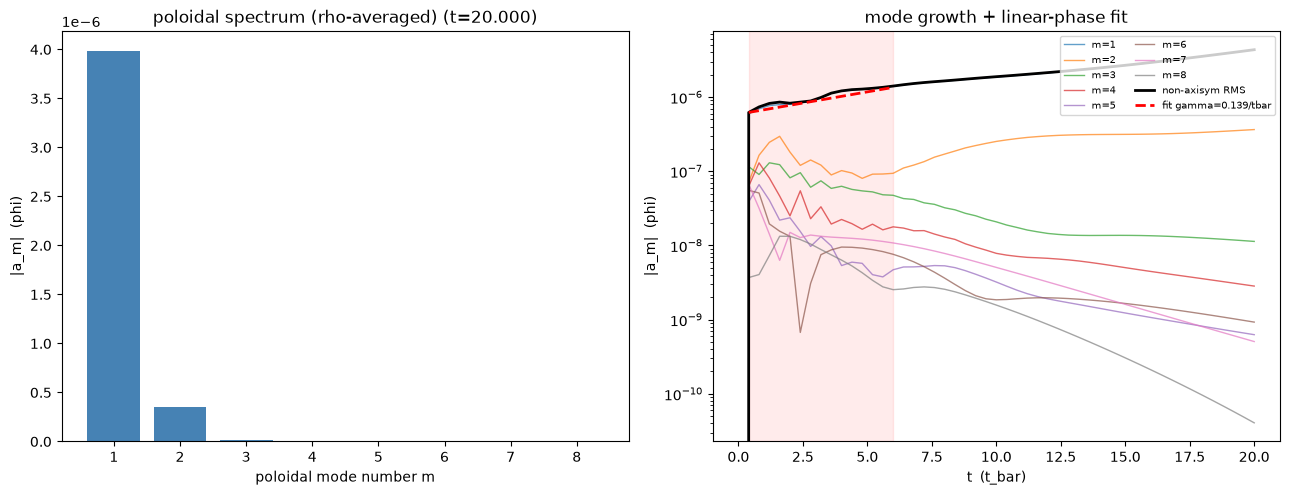

In [39]:
fig, (axS, axG) = plt.subplots(1, 2, figsize=(13, 5.2))
ms = np.arange(MMAX + 1)
axS.bar(ms[1:], A[-3, 1:], color="steelblue")
axS.set_xlabel("poloidal mode number m"); axS.set_ylabel(f"|a_m|  ({FIELD})")
axS.set_title(f"poloidal spectrum ({_rho_label()}) (t={t[-1]:.3f})")
for m in range(1, MMAX + 1):
    axG.semilogy(t, A[:, m], lw=1, alpha=0.7, label=f"m={m}")
axG.semilogy(t, A_tot, "k-", lw=2, label="non-axisym RMS")
if np.isfinite(g_tot):
    tf = t[band]
    axG.semilogy(tf, A_tot[band][0] * np.exp(g_tot * (tf - tf[0])), "r--", lw=2,
                 label=f"fit gamma={g_tot:.3f}/tbar")
    axG.axvspan(t0, t1, color="red", alpha=0.08)
axG.set_xlabel("t  (t_bar)"); axG.set_ylabel(f"|a_m|  ({FIELD})")
axG.set_title("mode growth + linear-phase fit"); axG.legend(fontsize=7, ncol=2, loc="upper right")
fig.tight_layout(); plt.show()

In [40]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

FIELD = "phi"
MMAX = 3
RHO = 0.3   # radius to sample the ring at

def der_t(a, t):
    """2nd-order central d/dt along axis 0, one-sided at the boundaries."""
    dt = t[1] - t[0]
    tdt = 1 / (2 * dt)
    inner = (a[2:] - a[:-2]) * tdt
    top = ((a[1] - a[0]) * (2.0 * tdt))[None]
    bot = ((a[-1] - a[-2]) * (2.0 * tdt))[None]
    return np.concatenate([top, inner, bot], axis=0)

def mode_amplitudes(ring, mmax):
    N = ring.size
    amp = np.abs(np.fft.rfft(ring) / N)
    amp[1:] *= 2.0
    return amp[: mmax + 1]

def ring_at_polar(field2d, r, rho):
    """field2d: (nr, ntheta) snapshot. r: (nr,) radial grid. Linear interpolation
    onto the ring at radius rho -- needs THIS run's own r grid, not a leftover
    one from a different run."""
    nr = r.size
    j = np.clip(np.searchsorted(r, rho), 1, nr - 1)
    w = (rho - r[j - 1]) / (r[j] - r[j - 1])
    return (1 - w) * field2d[j - 1] + w * field2d[j]

def compute_gamma_m(rundir, mmax=MMAX, field=FIELD, rho=RHO):
    """Loads one run's setup.h5/fields.h5 (polar), computes the poloidal
    mode-amplitude array A[frame, m] at radius rho, and returns, for each mode
    m=1..mmax, the masked (t, instantaneous gamma_m = d(log A_m)/dt)."""
    with h5py.File(os.path.join(rundir, "setup.h5"), "r") as s:
        r = np.asarray(s["r"], float)
    with h5py.File(os.path.join(rundir, "fields.h5"), "r") as fh:
        t = np.asarray(fh["t"], float)
        nf = fh[field].shape[0]
        A = np.zeros((nf, mmax + 1))
        for k in range(nf):
            field2d = np.asarray(fh[field][k])
            ring = ring_at_polar(field2d, r, rho)
            A[k] = mode_amplitudes(ring, mmax)

    per_mode = {}
    for m in range(1, mmax + 1):
        mask = A[:, m] > 0
        per_mode[m] = (t[mask], der_t(np.log(A[mask, m]), t[mask]))
    return per_mode


# ---- list every run you want on the same plot: label -> run directory ------
RUNS_TO_COMPARE = {
    "U=-1.2, H=10 rotation":    "/pscratch/sd/d/dnzy06/plasma_sim_runs/polar_200f_Um1.2_H10_smoothbiased_r2/55953318",
    "U=-1.2, H=10 no rotation": "/pscratch/sd/d/dnzy06/plasma_sim_runs/polar_200f_Um1.2_H10_r2/55953318",
    # "U=0, H=10 rotation":    "/pscratch/sd/d/dnzy06/plasma_sim_runs/polar_200f_U0_H10_smoothbiased_r2/55953318",
    # "U=0, H=10 no rotation": "/pscratch/sd/d/dnzy06/plasma_sim_runs/polar_200f_U0_H10_r2/55953318",
}

results = {}   # results[label] = {m: (t_masked, gamma_m_t)}
for label, rundir in RUNS_TO_COMPARE.items():
    try:
        results[label] = compute_gamma_m(rundir, mmax=MMAX)
    except Exception as e:
        print(f"skipping '{label}' ({rundir}): {e}")

if not results:
    raise SystemExit("no runs loaded successfully -- nothing to plot")

fig, axes = plt.subplots(MMAX, 1, figsize=(8, 3.0 * MMAX), sharex=True, squeeze=False)
axes = axes[:, 0]
colors = plt.cm.viridis(np.linspace(0, 1, max(len(results), 1)))

for m, ax in zip(range(1, MMAX + 1), axes):
    for (label, per_mode), c in zip(results.items(), colors):
        t_masked, gamma_t = per_mode[m]
        ax.plot(t_masked, gamma_t, lw=1.3, alpha=0.8, color=c, label=label)
    ax.set_ylabel(f"$\\gamma_{{{m}}}$")
    ax.set_title(f"m={m}", fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].legend(fontsize=7, ncol=1)
axes[-1].set_xlabel("t  (t_bar)")
fig.suptitle("instantaneous $\\gamma_m$ -- run comparison")
fig.tight_layout()
plt.show()

skipping 'U=-1.2, H=10 rotation' (/pscratch/sd/d/dnzy06/plasma_sim_runs/polar_200f_Um1.2_H10_smoothbiased_r2/55953318): [Errno 2] Unable to synchronously open file (unable to open file: name = '/pscratch/sd/d/dnzy06/plasma_sim_runs/polar_200f_Um1.2_H10_smoothbiased_r2/55953318/setup.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)
skipping 'U=-1.2, H=10 no rotation' (/pscratch/sd/d/dnzy06/plasma_sim_runs/polar_200f_Um1.2_H10_r2/55953318): [Errno 2] Unable to synchronously open file (unable to open file: name = '/pscratch/sd/d/dnzy06/plasma_sim_runs/polar_200f_Um1.2_H10_r2/55953318/setup.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)


SystemExit: no runs loaded successfully -- nothing to plot

In [28]:
# ---- radius-resolved mode spectrum (replaces the rho-averaging block) ----
N_RHO_POINTS = 60
rho_grid = np.linspace(0.1, LIMITER_RHO - 0.1, N_RHO_POINTS)   # same bounds convention as sample_rhos

field2d_final = np.asarray(fh[FIELD][-1])          # last frame; change index for a different snapshot

rings = ring_at(field2d_final, rho_grid)            # (N_RHO_POINTS, ntheta)
A_r = np.zeros((N_RHO_POINTS, MMAX + 1))            # A_r[i_rho, m]
for i in range(N_RHO_POINTS):
    A_r[i] = mode_amplitudes(rings[i], MMAX)

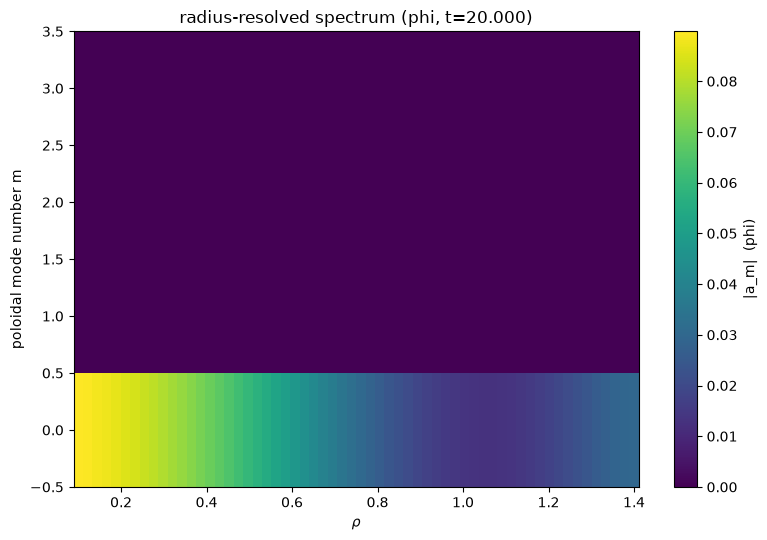

In [29]:
m_axis = np.arange(MMAX + 1)

fig, ax = plt.subplots(figsize=(8, 5.5))
pcm = ax.pcolormesh(rho_grid, m_axis, A_r.T, shading="auto",
                     vmin=0, vmax=A_r.max(), cmap="viridis")
ax.set_xlabel(r"$\rho$")
ax.set_ylabel("poloidal mode number m")
ax.set_title(f"radius-resolved spectrum ({FIELD}, t={t[-1]:.3f})")
fig.colorbar(pcm, ax=ax, label=f"|a_m|  ({FIELD})")
fig.tight_layout(); plt.show()

In [13]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Surface(
    x=rho_grid, y=m_axis, z=A_r.T,          # z shape must be (len(y), len(x)) -> (m, rho)
    colorscale="Viridis",
    cmin=0, cmax=A_r.max(),
    colorbar=dict(title=f"|a_m|  ({FIELD})"),
    hovertemplate="rho=%{x:.3f}<br>m=%{y}<br>|a_m|=%{z:.3e}<extra></extra>",
)])

fig.update_layout(
    title=f"radius-resolved spectrum ({FIELD}, t={t[-1]:.3f})",
    scene=dict(
        xaxis_title="rho",
        yaxis_title="m",
        zaxis_title=f"|a_m|  ({FIELD})",
    ),
    width=850, height=700,
)
fig.show()

In [40]:
# ---- precompute radius-resolved spectrum for every frame ----

A_r_all = np.zeros((nf, N_RHO_POINTS, MMAX + 1))   # A_r_all[frame, i_rho, m]
for k in range(nf):
    field2d = np.asarray(fh[FIELD][k])
    rings = ring_at(field2d, rho_grid)              # (N_RHO_POINTS, ntheta)
    for i in range(N_RHO_POINTS):
        A_r_all[k, i] = mode_amplitudes(rings[i], MMAX)

zmax = A_r_all.max()   # fixed color/z scale across all frames so the slider doesn't rescale each step

In [41]:
import plotly.graph_objects as go

# initial frame shown on load
k0 = 0
fig = go.Figure(
    data=[go.Surface(
        x=rho_grid, y=m_axis, z=A_r_all[k0].T,
        colorscale="Viridis", cmin=0, cmax=zmax,
        colorbar=dict(title=f"|a_m|  ({FIELD})"),
        hovertemplate="rho=%{x:.3f}<br>m=%{y}<br>|a_m|=%{z:.3e}<extra></extra>",
    )],
    frames=[
        go.Frame(
            data=[go.Surface(x=rho_grid, y=m_axis, z=A_r_all[k].T,
                              colorscale="Viridis", cmin=0, cmax=zmax)],
            name=str(k),
        )
        for k in range(nf)
    ],
)

fig.update_layout(
    title=f"radius-resolved spectrum ({FIELD}), frame {k0} (t={t[k0]:.3f})",
    scene=dict(
        xaxis_title="rho", yaxis_title="m", zaxis_title=f"|a_m|  ({FIELD})",
        zaxis=dict(range=[0, zmax]),
    ),
    width=850, height=700,
    updatemenus=[dict(
        type="buttons", showactive=False,
        y=0, x=0.05, xanchor="left", yanchor="top",
        buttons=[
            dict(label="Play", method="animate",
                 args=[None, dict(frame=dict(duration=80, redraw=True), fromcurrent=True)]),
            dict(label="Pause", method="animate",
                 args=[[None], dict(frame=dict(duration=0, redraw=False), mode="immediate")]),
        ],
    )],
    sliders=[dict(
        active=k0,
        currentvalue=dict(prefix="frame: "),
        steps=[
            dict(method="animate",
                 args=[[str(k)], dict(mode="immediate",
                                       frame=dict(duration=0, redraw=True))],
                 label=f"{k} (t={t[k]:.2f})")
            for k in range(nf)
        ],
    )],
)
fig.show()

## 3. Growth-rate spectrum — γ(m) vs poloidal mode number

The **interchange dispersion**: per-mode linear growth rate `γ_m` versus `m`. Without
FLR (`U=0`) γ increases with m (no short-wavelength cutoff → broadband); with FLR
(`U<0`) the high-m modes are stabilized and a single low-m mode dominates.

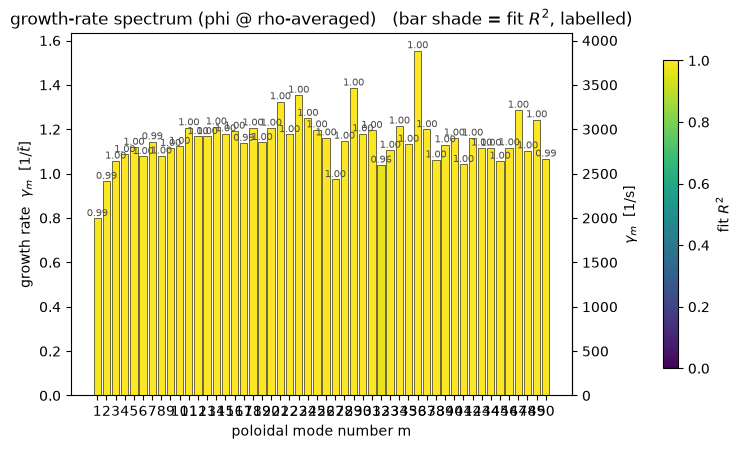

fastest-growing well-fit mode: m=36  gamma=1.555/t_bar = 3.887e+03/s  (R^2=1.00)


In [21]:
def growth_rate_spectrum(A, t, lo=LO, hi=HI):
    """Per-mode linear growth rate gamma_m, fit R^2, and the auto-detected fit
    time window [t0_m, t1_m] (+ boolean frame-mask) for m=1..MMAX."""
    mmax = A.shape[1] - 1
    gm = np.full(mmax + 1, np.nan); r2m = np.full(mmax + 1, np.nan)
    t0m = np.full(mmax + 1, np.nan); t1m = np.full(mmax + 1, np.nan)
    masks = [np.zeros(A.shape[0], bool) for _ in range(mmax + 1)]
    for m in range(1, mmax + 1):
        g, t0, t1, r2, mask = fit_growth_manual(t, A[:, m], T0_MANUAL, T1_MANUAL)
        gm[m], r2m[m], t0m[m], t1m[m] = g, r2, t0, t1
        masks[m] = mask
    return gm, r2m, t0m, t1m, masks

def plot_growth_vs_m(A, t, t_bar, lo=LO, hi=HI, field=FIELD, rho=None):
    """Bar plot of gamma_m vs poloidal mode m, shaded by fit R^2; right axis in 1/s."""
    gm, r2m, *_ = growth_rate_spectrum(A, t, lo, hi)
    ms = np.arange(1, A.shape[1]); g = gm[1:]; r2 = np.nan_to_num(r2m[1:])
    fig, ax = plt.subplots(figsize=(7.8, 4.6))
    ax.bar(ms, g, color=plt.cm.viridis(np.clip(r2, 0, 1)), edgecolor="k", lw=0.4)
    for mi, gi, ri in zip(ms, g, r2):
        if np.isfinite(gi):
            ax.annotate(f"{ri:.2f}", (mi, gi), ha="center",
                        va="bottom" if gi >= 0 else "top", fontsize=7, color="0.3")
    ax.axhline(0, color="k", lw=0.6)
    ax.set_xlabel("poloidal mode number m"); ax.set_xticks(ms)
    ax.set_ylabel(r"growth rate  $\gamma_m$  [1/$\bar t$]")
    if isinstance(rho, str):
        rho_txt = f" @ {rho}"
    elif rho:
        rho_txt = f" @ rho={rho:.2f} L0"
    else:
        rho_txt = ""
    ttl = f"growth-rate spectrum ({field}{rho_txt})"
    ax.set_title(ttl + "   (bar shade = fit $R^2$, labelled)")
    ax.secondary_yaxis("right", functions=(lambda v: v / t_bar, lambda v: v * t_bar)
                       ).set_ylabel(r"$\gamma_m$  [1/s]")
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(0, 1)); sm.set_array([])
    fig.colorbar(sm, ax=ax, label="fit $R^2$", pad=0.13, shrink=0.85)
    fig.tight_layout(); plt.show()
    return gm, r2m

# A, t, rho come from section 2; run that first.
gm, r2m = plot_growth_vs_m(A, t, t_bar, rho=(_rho_label() if RHO_AVERAGED else rho))
best = int(np.nanargmax(np.where(np.nan_to_num(r2m) > 0.5, gm, np.nan))) \
    if np.any(np.nan_to_num(r2m) > 0.5) else int(np.nanargmax(gm))
print(f"fastest-growing well-fit mode: m={best}  gamma={gm[best]:.3f}/t_bar "
      f"= {gm[best]/t_bar:.3e}/s  (R^2={r2m[best]:.2f})")

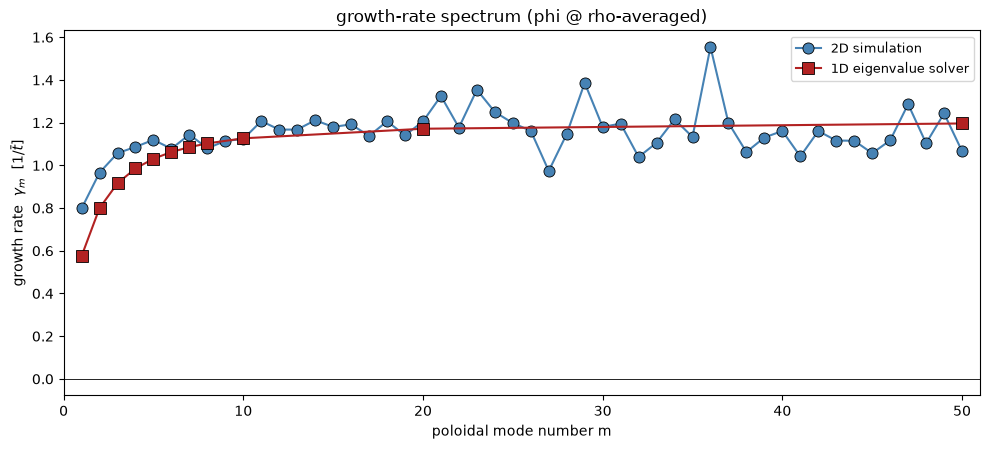

fastest-growing well-fit mode: m=36  gamma=1.555/t_bar = 3.887e+03/s  (R^2=1.00)


In [24]:
def plot_growth_vs_m(A, t, t_bar, lo=LO, hi=HI, field=FIELD, rho=None,
                      eig_m=None, eig_gamma=None):
    """Scatter+line plot of gamma_m vs poloidal mode m, with an optional overlay
    of the 1D eigenvalue solver's gamma(m) for direct comparison."""
    gm, r2m, *_ = growth_rate_spectrum(A, t, lo, hi)
    ms = np.arange(1, A.shape[1]); g = gm[1:]
    fig, ax = plt.subplots(figsize=(10, 4.6))
    ax.plot(ms, g, "-o", ms=8, color="steelblue", markeredgecolor="k",
            markeredgewidth=0.6, lw=1.5, zorder=3, label="2D simulation")

    if eig_m is not None and eig_gamma is not None:
        eig_m = np.asarray(eig_m); eig_gamma = np.asarray(eig_gamma)
        ax.plot(eig_m, eig_gamma, "-s", ms=8, color="firebrick", markeredgecolor="k",
                markeredgewidth=0.6, lw=1.5, zorder=3, label="1D eigenvalue solver")
        xmin = min(ms.min(), eig_m.min()) - 1
        xmax = max(ms.max(), eig_m.max()) + 1
    else:
        xmin, xmax = ms.min() - 1, ms.max() + 1

    ax.axhline(0, color="k", lw=0.6)
    ax.set_xlabel("poloidal mode number m")
    ax.set_xlim(xmin, xmax)
    ax.set_ylabel(r"growth rate  $\gamma_m$  [1/$\bar t$]")
    if isinstance(rho, str):
        rho_txt = f" @ {rho}"
    elif rho:
        rho_txt = f" @ rho={rho:.2f} L0"
    else:
        rho_txt = ""
    ax.set_title(f"growth-rate spectrum ({field}{rho_txt})")
    if eig_m is not None and eig_gamma is not None:
        ax.legend(fontsize=9)
    fig.tight_layout(); plt.show()
    return gm, r2m

# 1D eigenvalue solver results, for overlay
m_values_1d = [1, 2, 3, 4, 5, 6, 7, 8, 10, 20, 50]
# gamma_values_1d = np.asarray([0.55454039, 0.77206174, 0.872199  , 0.92271399, 0.94634884,
#        0.95342632, 0.94932112, 0.93711274, 0.89534247,  0.49720141, -1.88754846])

gamma_values_1d = np.asarray([0.57504115, 0.80006263, 0.91610202, 0.98556324, 1.03098172,
       1.06253893, 1.08547058, 1.10272402, 1.12664568, 1.17153795,
       1.19621692])

# A, t, rho come from section 2; run that first.
gm, r2m = plot_growth_vs_m(A, t, t_bar, rho=(_rho_label() if RHO_AVERAGED else rho),
                           eig_m=m_values_1d, eig_gamma=gamma_values_1d)
best = int(np.nanargmax(np.where(np.nan_to_num(r2m) > 0.5, gm, np.nan))) \
    if np.any(np.nan_to_num(r2m) > 0.5) else int(np.nanargmax(gm))
print(f"fastest-growing well-fit mode: m={best}  gamma={gm[best]:.3f}/t_bar "
      f"= {gm[best]/t_bar:.3e}/s  (R^2={r2m[best]:.2f})")

## 5. Energy confinement time

Total stored pressure/energy `W(t) = ∫P dA` and an instantaneous confinement time
`tau_E(t) = W(t)/L(t)`, where `L(t)` is the net loss rate.  `L` is computed two ways:

1. **Robust (always works):** `L = -dW/dt`, finite-differenced directly from the saved
   frames. This measures *whatever* net rate the total pressure is actually changing,
   regardless of which RHS terms do or don't integrate to zero for a given coordinate
   system/BC -- no assumptions needed.
2. **Direct cross-check (best-effort):** `L_direct = ∫ nu5p(r)*P dA`, summing only the
   axial/parallel-loss term. On a periodic Cartesian domain, advection and diffusion
   integrate to exactly zero, so this should match method 1 closely; on the polar grid
   (Dirichlet outer BC) it's only approximate, since the limiter sponge -- not an exact
   periodicity argument -- is what keeps the boundary flux negligible.

The dashed reference line is the *ideal* confinement time `1/nu5p` (the base, inside-limiter
rate) -- the ceiling you'd get with only axial losses and no instability-driven transport.

In [41]:
# --- coordinate-aware cell area element dA ---
if COORD_EFF == "polar":
    dr = r[1] - r[0]; dth = theta[1] - theta[0]
    dA = (r * dr * dth)[:, None]              # (nr,1) broadcasts over theta -> (nr,ntheta)
    dA = dA * (r < LIMITER_RHO)[:, None]
else:
    dx_ = x[1] - x[0]; dy_ = y[1] - y[0]
    dA = dx_ * dy_                             # scalar, uniform Cartesian cell area

# --- W(t): total stored pressure ("energy") each saved frame ---
W = np.array([np.sum(np.asarray(fh["pres"][k]) * dA) for k in range(nf)])

# --- L(t) method 1: robust, model-agnostic instantaneous loss rate ---
L_grad = -np.gradient(W, t)

# --- confinement time(s) ---
with np.errstate(divide="ignore", invalid="ignore"):
    tau_grad = np.where(L_grad > 0, W / L_grad, np.nan)

nu5p_base = attrs.get("nu5p")
tau_ideal = 1.0 / nu5p_base if nu5p_base else None

print(f"W(t=0)={W[0]:.4e}  W(t={t[-1]:.3f})={W[-1]:.4e}  (normalized pressure units)")
print(f"tau_E [dW/dt method]:   final = {tau_grad[-1]:.3f} t_bar = {tau_grad[-1]*t_bar*1e3:.3f} ms")


W(t=0)=2.8152e+00  W(t=20.000)=3.2623e+00  (normalized pressure units)
tau_E [dW/dt method]:   final = nan t_bar = nan ms


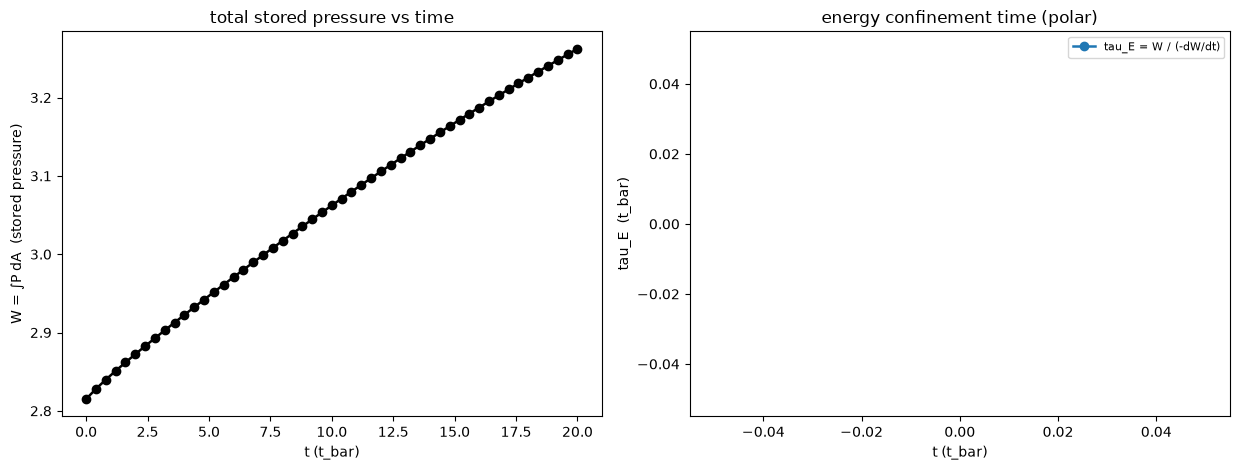

In [42]:
fig, (axW, axT) = plt.subplots(1, 2, figsize=(12.5, 4.8))

axW.plot(t, W, "-o", color="k", lw=1.8)
axW.set_xlabel("t (t_bar)"); axW.set_ylabel("W = ∫P dA  (stored pressure)")
axW.set_title("total stored pressure vs time")

axT.plot(t, tau_grad, '-o', lw=1.8, label="tau_E = W / (-dW/dt)")

axT.set_xlabel("t (t_bar)"); axT.set_ylabel("tau_E  (t_bar)")
axT.set_title(f"energy confinement time ({COORD_EFF})")
axT.legend(fontsize=8)
fig.tight_layout(); plt.show()

## 5. b) Small variation on energy confinement time

## 6. Compare energy confinement time across multiple runs

Same `tau_E = W / (-dW/dt)` calculation as Section 5, but repackaged as a function
(`compute_tau_E`) that opens *its own* `setup.h5`/`fields.h5` for a given run folder --
it does not depend on whatever is loaded in the Section 0 "Load data" cell, so it can
be called once per run you want to compare.

**How the data gets loaded:** for each folder path you list in `RUNS_TO_COMPARE`, the
function (1) opens that run's `setup.h5` to detect `coord_type` (cart vs polar) and
build the matching cell-area element `dA`, (2) opens `fields.h5` and sums `pres * dA`
over the whole grid for every saved frame to get `W(t)`, (3) finite-differences `W(t)`
to get the loss rate and `tau_E(t) = W/(-dW/dt)`. The results for every run are kept in
a plain dict (`results`), then plotted together in the next cell.

In [26]:
def compute_tau_E(rundir, core_only=False):
    """Load ONE run from `rundir` (a folder containing setup.h5 + fields.h5) and
    compute W(t) and tau_E(t) = W/(-dW/dt).  Self-contained: detects cart vs polar
    from setup.h5's coord_type attribute and builds the matching area element, so it
    works regardless of which run (if any) is loaded in the Section 0 cell above.

    core_only=True restricts W(t) to r < limiter_radius -- i.e. it excludes whatever
    pressure is sitting in the enhanced-loss "shadow" zone beyond the limiter (which
    otherwise still counts toward W(t) while it slowly drains at the 20x rate). This
    focuses the confinement-time measure on the confined core, rather than the whole
    simulated box, and is closer to what "energy confinement time" usually means."""
    with h5py.File(os.path.join(rundir, "setup.h5"), "r") as s:
        attrs_ = dict(s.attrs)
        coord_ = attrs_.get("coord_type", "cart")
        lim_r = attrs_.get("limiter_radius")
        if coord_ == "polar":
            r_ = np.asarray(s["r"], float); th_ = np.asarray(s["theta"], float)
            dA_ = (r_ * (r_[1] - r_[0]) * (th_[1] - th_[0]))[:, None]
            if core_only and lim_r is not None:
                dA_ = dA_ * (r_ < lim_r)[:, None]          # zero weight beyond limiter
        else:
            x_ = np.asarray(s["x"], float); y_ = np.asarray(s["y"], float)
            dA_ = (x_[1] - x_[0]) * (y_[1] - y_[0])
            if core_only and lim_r is not None:
                r2_ = np.asarray(s["r2"])                  # precomputed X^2+Y^2 field
                dA_ = dA_ * (r2_ < lim_r * lim_r)          # zero weight beyond limiter

    with h5py.File(os.path.join(rundir, "fields.h5"), "r") as f:
        t_ = np.asarray(f["t"], float)
        nf_ = f["pres"].shape[0]
        W_ = np.array([np.sum(np.asarray(f["pres"][k]) * dA_) for k in range(nf_)])

    with np.errstate(divide="ignore", invalid="ignore"):
        tau_ = np.where(-np.gradient(W_, t_) > 0, W_ / -np.gradient(W_, t_), np.nan)

    nu5p_base_ = attrs_.get("nu5p")
    return {"t": t_, "W": W_, "tau_E": tau_,
            "tau_ideal": (1.0 / nu5p_base_ if nu5p_base_ else None),
            "coord": coord_, "core_only": core_only}

In [28]:
# --- list every run you want on the same plot: label -> path to its run directory ---
RUNS_TO_COMPARE = {
    # "U=-1.2, H=10 rotation":     "/pscratch/sd/d/dnzy06/plasma_sim_runs/polar_200f_Um1.2_H10_smoothbiased_r2/55953318",          # <<< fill in the actual folder (ls runs/polar/)
    "U=-1.2, H=10 rotation": "/pscratch/sd/d/dnzy06/plasma_sim_runs/bayesian_opt/trial_00220/55962208",
    "U=-1.2, H=10 no rotation":    "/pscratch/sd/d/dnzy06/plasma_sim_runs/polar_200f_Um1.2_H10_r2/55953318",
    # "U=0, H=10 rotation":    "/pscratch/sd/d/dnzy06/plasma_sim_runs/polar_200f_U0_H10_smoothbiased_r2/55953318",
    # "U=0, H=10 no rotation":    "/pscratch/sd/d/dnzy06/plasma_sim_runs/polar_200f_U0_H10_r2/55953318",
}

results = {}
for label, path in RUNS_TO_COMPARE.items():
    try:
        results[label] = compute_tau_E(path, core_only=True)
    except Exception as e:
        print(f"skipping '{label}' ({path}): {e}")

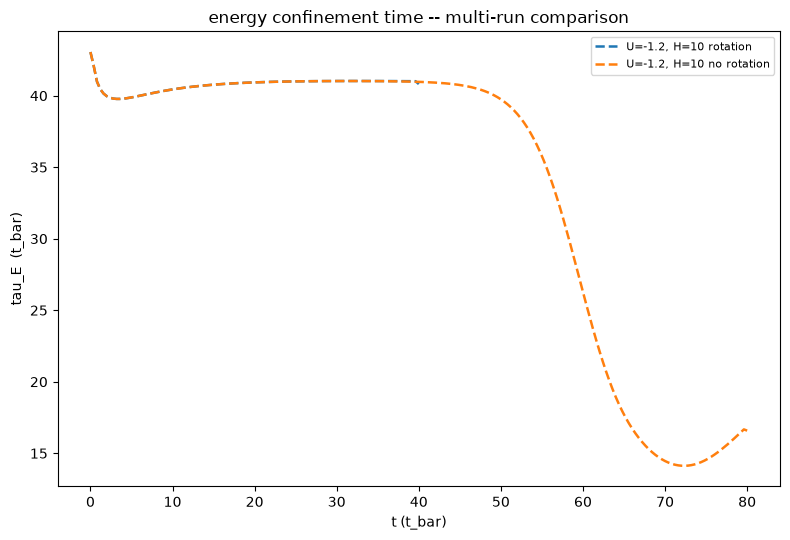

In [29]:
colors = ['C0', 'C1', 'C2', 'C3']

fig, ax = plt.subplots(figsize=(8, 5.5))
for label, res in results.items():
    ax.plot(res["t"], res["tau_E"], '--', lw=1.8, label=f"{label}", color=colors.pop(0))
ax.set_xlabel("t (t_bar)"); ax.set_ylabel("tau_E  (t_bar)")
ax.set_title("energy confinement time -- multi-run comparison")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

## 9. Area-averaged normalized pressure fluctuation |δP|/P vs time

`deltaP(x,y,t) = P(x,y,t) - <P>(t)`, where `<P>(t)` is the area-weighted
spatial mean of P at that frame. The ratio `|deltaP|/P` is averaged over
the domain (area-weighted, coordinate-aware via the `dA` from Section 5 --
run the Load data + Section 5 area-element cell first). Points where `|P|`
is numerically ~0 (deep in the limiter shadow) are excluded from both the
average and its weight, since dividing by ~0 there would blow up a ratio
that isn't physically meaningful.

In [ ]:
# --- Area-averaged normalized pressure fluctuation |deltaP|/P vs time ---
# Needs: fh, t, nf, COORD_EFF (Load data cell) and dA, x/y or r/theta
# (Section 5 area-element cell) already run.

P_FLOOR_FRAC = 1e-6   # exclude |P| < P_FLOOR_FRAC * max|P0| from the ratio

if COORD_EFF == "polar":
    _ones = np.ones((r.size, theta.size))
else:
    _ones = np.ones((y.size, x.size))
area_total = np.sum(dA * _ones)

P0 = np.asarray(fh["pres"][0])
p_floor = P_FLOOR_FRAC * np.abs(P0).max()

rel_fluc = np.full(nf, np.nan)
for k in range(nf):
    P = np.asarray(fh["pres"][k])
    w = dA * _ones
    Pmean = np.sum(P * w) / area_total
    dP = P - Pmean
    valid = np.abs(P) > p_floor
    w_valid = w * valid
    denom = w_valid.sum()
    if denom > 0:
        rel_fluc[k] = np.sum(np.abs(dP) / np.where(valid, P, 1.0) * w_valid) / denom

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.plot(t, rel_fluc, "-o", ms=3, lw=1.5)
ax.set_xlabel("t (t_bar)"); ax.set_ylabel(r"area-avg $|\delta P|/P$")
ax.set_title(f"normalized pressure fluctuation level ({COORD_EFF})")
fig.tight_layout(); plt.show()

print(f"|dP|/P: t={t[0]:.3f} -> {rel_fluc[0]:.3e}   t={t[-1]:.3f} -> {rel_fluc[-1]:.3e}")